# Project Introduction

Welcome to my portfolio!

I am Marcin Deszczka, a data analyst specializing in marketing analytics. For this analysis, I selected the demo database [Influencer Marketing Campaign Analysis from Kaggle](https://www.kaggle.com/datasets/divyamehulmak/influencer-marketing-campaign-analysis-power-bi/).

## About the Database
The selected dataset is a synthetic yet highly realistic representation of influencer marketing campaigns in the fashion industry. It is designed to faithfully simulate real-world customer-product-campaign interactions, enabling in-depth analysis of marketing effectiveness, return on investment (ROI), and consumer behavior.

The database structure covers key areas:
* Influencers (20 unique): data on Follower_Count, platform, tier, location, engagement, and audience demographics.
* Campaigns (10 unique): budget, duration, product category, primary goal, and platform.
* Products (25 unique): categories, subcategories, target gender, seasonality, pricing, and launch dates.
* Orders (over 100k rows): mappings of customers, products, influencers, Campaign_ID, discount codes, and Revenue_Generated amounts.
* Customer Demographics (over 90k unique users): age, gender, location, income bracket, preferred style, new customer status, and Customer Lifetime Value (CLV).

This dataset enables, among other things, tracking revenue and conversions, analyzing campaign effectiveness based on duration or influencer tier and customer segmentation and purchasing pattern research.

The SQL and Python data come from the same source (Kaggle) but were prepared independently —
* SQL in an SQLite file manually configured in DB Browser after creating a database in a .db file imported from a .csv file, which had previously been imported from the original .xlsx file. This process allowed me to achieve a fast data import into the .db file and manual verification of data cleanliness, where I manually edited incorrect data types. Subsequently, using Python code, I replaced commas with dots, as commas had appeared incorrectly during the format conversion to .csv. (tu kończyłem sprawdzać!)
* In the case of Python, directly from .xlsx files.

*The data is for demonstration purposes and is not real, which is why financial results like ROI look rather unrealistic. This in no way affects my methodology. We considered the US dollar as the settlement currency in the data.*

## Technological Approach
For the analysis, I chose two complementary languages – **SQL** and **Python**. Jupyter Notebook serves as the presentation format for code and results, perfectly suited for creating clear, interactive reports. Furthermore, I utilized the SQLite SQL dialect (starting cells with the `%%sql` expression), which allows for seamlessly combining the power of database queries with the flexibility of the Python ecosystem. Within Python, I used pandas, seaborn, matplotlib.pyplot, numpy, openpyxl, plotly, IPython.display, and re libraries, and I also assisted myself with artificial intelligence. The SQL code was written entirely by a human.

## Table of Contents

**Part I — SQL**
- *Task 1: Influencer Segmentation — Data Consistency Audit*
- *Task 2: Campaign Aggregation*
- *Task 3: Comprehensive Influencer Performance Profile*
- *Task 4: Creators Selection Above Average*
- *Task 5: ROI Benchmark by Platform*
- *Task 6: Month-over-Month (MoM) Revenue Trend*

**Part II — Python**
- *Data Loading and Quality Verification*
- *Task 7: Impact of Product Category on Campaign Effectiveness*
- *Task 8: Revenue Flow Visualization (Sankey)*

**[Final Summary](#summary)**


## Task 1: Influencer Segmentation by Size — Data Consistency Audit

### Business Context
The `influencers` table already contains a pre-built `Tier` column, assigning each influencer to a size category (`Nano`, `Micro`, `Mid`, `Macro`). In real-world client data analysis, it is not always clear what precise thresholds were used to create such a column, whether they are current, or whether the assignments contain errors (such as manual corrections, outdated thresholds, or typos). Before trusting a pre-built field, it is essential to verify it against an independently calculated classification.

### Analytical Objective
Recreate the influencer classification based on Follower_Count, using the following thresholds:

| Follower Count | Category |
| :--- | :--- |
| < 10,000 | `Nano` |
| 10,000 – 49,999 | `Micro` |
| 50,000 – 499,999 | `Mid` |
| $\ge$ 500,000 | `Macro` |

Next, compare the result with the value in the existing `Tier` column and identify any discrepancies.

---

### Analytical Requirements
* **Required output columns:**
  * `Name`
  * `Follower_Count`
  * `Tier` (Original value from the `influencers` table)
  * `Calculated_Category` (Category calculated independently based on the thresholds above)
  * `Match_Status` (Indicates whether `Tier` and `Calculated_Category` match, e.g., `OK` / `NO`)
* **Sorting:** Sort the result in descending order by `Follower_Count`.
* **Discrepancy Analysis:** Count the total number of `NO` rows — if any occur, consider potential causes (such as different numerical thresholds used during data generation, manual errors, or outdated classification following a change in follower count).

In [26]:
%load_ext sql
%sql sqlite:///influ_base.db
%config SqlMagic.style = '_DEPRECATED_DEFAULT'

The sql extension is already loaded. To reload it, use:
  %reload_ext sql


In [27]:
%%sql

WITH Calculated AS (
    SELECT 
        Name, 
        Follower_Count, 
        Tier,
        CASE 
            WHEN Follower_Count < 10000 THEN 'Nano'
            WHEN Follower_Count BETWEEN 10000 AND 49999 THEN 'Micro'
            WHEN Follower_Count BETWEEN 50000 AND 499999 THEN 'Mid'
            ELSE 'Macro'
        END AS Calculated_Category
    FROM influencers
)

SELECT 
    c.Name, 
    c.Follower_Count AS Number_of_Followers,
    c.Tier, 
    c.Calculated_Category, 
    CASE 
        WHEN c.Tier = c.Calculated_Category THEN 'OK'
        ELSE 'NO'
    END AS Match_Status
FROM Calculated AS c
ORDER BY c.Follower_Count DESC

 * sqlite:///influ_base.db
Done.


Name,Number_of_Followers,Tier,Calculated_Category,Match_Status
BeautyBuzz,1888335.0,Mega,Macro,NO
VintageFinds,1304403.0,Mega,Macro,NO
SustainableChic,1142316.0,Mega,Macro,NO
QuickStyleTips,844915.0,Macro,Macro,OK
MinimalistMan,770885.0,Macro,Macro,OK
TheStreetLook,749531.0,Macro,Macro,OK
TravelAndStyle,459074.0,Macro,Mid,NO
FormalWearPro,409549.0,Macro,Mid,NO
VibeGuru,326621.0,Macro,Mid,NO
DailyDrapes,311330.0,Macro,Mid,NO


The analysis indicates that my proposed influencer tier system differs from the tier system in the database, specifically across 13 cases. Notably, the database includes a category that does not fit into my proposed system—the Mega category for top-tier influencers. The 13 discrepancies do not stem from isolated data errors but rather from a fundamentally different classification logic. The tier in the source database is not based on follower count thresholds but on ranking position: the top 3 influencers are Mega, the next 9 are Macro, the following 4 are Micro, and the last 4 are Nano, regardless of the specific Follower_Count value. This highlights the critical importance of verifying classification assumptions prior to further analysis; applying absolute thresholds instead of ranking would yield a completely different segment distribution.

13 out of 20 influencers (65%) are classified differently than in our proposed tier system.


## Task 2: Campaign Aggregation

For each campaign, calculate the key performance indicators:
* Total revenue generated (`Revenue_Generated`)
* Total cost (`Cost`)
* Average return on investment (`ROI`)

In [28]:

%%sql
SELECT Campaign_ID, 
    ROUND(SUM(Revenue_Generated), 2) AS Total_Revenue, 
    ROUND(SUM(Cost), 2) AS Total_Cost, 
    ROUND((SUM(Revenue_Generated) - SUM(Cost)) * 1.0 / SUM(Cost), 2) AS ROI
FROM performance
GROUP BY Campaign_ID
ORDER BY ROI DESC

 * sqlite:///influ_base.db
Done.


Campaign_ID,Total_Revenue,Total_Cost,ROI
CMP009,41951069.11,240000.0,173.8
CMP002,28113367.22,174900.0,159.74
CMP007,40816615.18,291900.0,138.83
CMP004,40476768.64,291900.0,137.67
CMP006,42983861.34,312900.0,136.37
CMP003,27809552.3,219000.0,125.98
CMP001,42268807.29,336000.0,124.8
CMP010,31836115.91,294000.0,107.29
CMP008,27983708.3,336000.0,82.28
CMP005,28611030.05,411000.0,68.61


Campaign 9 achieved the highest ROI (173.8), followed by campaigns 2 and 7. The lowest result was recorded by campaign 5 (68.61), with campaigns 8 and 10 performing slightly better. However, it is worth noting that every campaign achieved a positive and high ROI. The highest ROI was achieved by CMP009 (173.8), indicating that the net profit of this campaign was ~174 times greater than the incurred cost. Subsequent positions were secured by CMP002 (159.74) and CMP007 (138.83). The lowest ROI was obtained by CMP005 (68.61), with CMP008 (82.28) and CMP010 (107.29) performing slightly higher.

It should be emphasized that all campaigns achieved positive and high ROI. *The data is synthetic, so the financial results are unrealistically high; however, this does not affect the analysis methodology.*

<a id="task3"></a>
## Task 3: Comprehensive Influencer Performance Profile

Combine data from the influencer tables and campaign results to create a cohesive performance profile for each creator.

### Analytical Requirements:
* **Identification data:** Influencer name (`Name`) and location (`Location`).
* **Operational and outcome metrics:**
  * Number of unique campaigns participated in (`Campaign_ID`)
  * Total conversions (`Conversions`)
  * Total revenue generated (`Revenue_Generated`)
* **Structural condition:** Each influencer should appear in the summary **at most once**.

In [29]:
%%sql
SELECT
i.Influencer_ID, i.Name, i.Location, SUM(p.Conversions) AS "Sum of Conversion" , ROUND(SUM(p.Revenue_Generated),2) AS "Sum of Revenues", COUNT(DISTINCT(p.Campaign_ID)) AS "Number of Campaigns"
FROM
influencers AS i
LEFT JOIN
performance AS p
ON 
i.Influencer_ID = p.Source_Influencer_ID
GROUP BY
i.Influencer_ID
ORDER BY "Sum of Revenues" DESC

 * sqlite:///influ_base.db
Done.


Influencer_ID,Name,Location,Sum of Conversion,Sum of Revenues,Number of Campaigns
INF008,BeautyBuzz,Rajasthan,22719,81431805.19,7
INF019,SustainableChic,Odisha,19203,71724149.04,6
INF012,VintageFinds,Andhra Pradesh,17214,53300996.42,5
INF020,PartyVibes,Delhi,6746,25406192.64,6
INF017,MomStyle,Madhya Pradesh,7469,24931698.25,6
INF014,QuickStyleTips,Tamil Nadu,6273,21221012.2,5
INF005,DailyDrapes,Bihar,4211,13382267.28,4
INF002,VibeGuru,Odisha,3291,12971115.7,3
INF007,MinimalistMan,Rajasthan,2244,9710044.83,2
INF004,TheStreetLook,Odisha,2262,9458214.23,2


In terms of total conversions and revenue, influencers such as BeautyBuzz, SustainableChic, and VintageFinds lead the ranking. BeautyBuzz has participated in the highest number of campaigns—7 campaigns—and has achieved the highest total conversions and revenue, while influencers such as SustainableChic, PartyVibes, and MomStyle have each completed 6 campaigns. There are also individuals with zero campaigns, revenue, and conversions: FormalWearPro, CollegeFashion, LuxuryLiving, and AthleticFit. It is worth noting that a higher number of conversions and revenue depends on the number of campaigns. Therefore, I decided to calculate the average for each influencer in the next table.

In [30]:
%%sql
SELECT
i.Influencer_ID, i.Name, i.Location, SUM(p.Conversions) AS "Sum of Conversion" , ROUND(SUM(p.Revenue_Generated),2) AS "Sum of Revenues", COUNT(DISTINCT(p.Campaign_ID)) AS "Number of Campaigns", 
(SUM(p.Conversions)*1.0/COUNT(DISTINCT p.Campaign_ID)) AS "Average of Conversion", ROUND(SUM(p.Revenue_Generated)*1.0 / COUNT(DISTINCT p.Campaign_ID), 2) AS "Average of Revenues"
FROM
influencers AS i
LEFT JOIN
performance AS p
ON 
i.Influencer_ID = p.Source_Influencer_ID
GROUP BY
i.Influencer_ID
ORDER BY "Average of Revenues" DESC

 * sqlite:///influ_base.db
Done.


Influencer_ID,Name,Location,Sum of Conversion,Sum of Revenues,Number of Campaigns,Average of Conversion,Average of Revenues
INF019,SustainableChic,Odisha,19203,71724149.04,6,3200.5,11954024.84
INF008,BeautyBuzz,Rajasthan,22719,81431805.19,7,3245.5714285714284,11633115.03
INF012,VintageFinds,Andhra Pradesh,17214,53300996.42,5,3442.8,10660199.28
INF007,MinimalistMan,Rajasthan,2244,9710044.83,2,1122.0,4855022.42
INF004,TheStreetLook,Odisha,2262,9458214.23,2,1131.0,4729107.12
INF002,VibeGuru,Odisha,3291,12971115.7,3,1097.0,4323705.23
INF014,QuickStyleTips,Tamil Nadu,6273,21221012.2,5,1254.6,4244202.44
INF020,PartyVibes,Delhi,6746,25406192.64,6,1124.3333333333333,4234365.44
INF017,MomStyle,Madhya Pradesh,7469,24931698.25,6,1244.8333333333333,4155283.04
INF010,TravelAndStyle,Odisha,2202,8074643.69,2,1101.0,4037321.84


The average conversion rate is highest for the influencers we mentioned before: VintageFinds, BeautyBuzz, and SustainableChic. But it is worth paying attention to users with a few campaigns who have strong average conversions. TheStreetLook, MinimalistMan and TravelAndStyle (all with two campaigns each) achieve average conversion numbers (ranging between 1,101 and 1,131) comparable to PartyVibes, who has six campaigns. This shows how well these influencers work and why they should be used in new campaigns. MinimalistMan, TheStreetLook (2 campaigns), and VibeGuru (3 campaigns) do really well in terms of average revenue per campaign, doing better than more experienced influencers such as QuickStyleTips (5 campaigns) and PartyVibes (6 campaigns). So I suggest giving more campaigns to MinimalistMan, TheStreetLook and VibeGuru, because they get great results even though they don't have as many campaigns.

<a id="task4"></a>
## Task 4: Selection of Creators Above Average
Write a query to identify influencers who generate a total revenue (`Revenue_Generated`) above the average of all creators.

### Analytical Requirements:
* **Identification data:** Influencer name (`Name`) and their total revenue generated.
* **Selection condition:** Display only those influencers whose total revenue exceeds the average total revenue calculated across all creators.
* **Calculation principle:** Do not compute the average from all rows or posts. First, aggregate (sum) the revenue for each influencer individually, and only then calculate the average from those values.

In [31]:
%%sql

SELECT i.Name, p.Source_Influencer_ID, SUM(p.Revenue_Generated) AS "Sum of Revenues"
FROM Performance AS p
JOIN Influencers AS i
ON i.Influencer_ID = p.Source_Influencer_ID
GROUP BY Source_Influencer_ID
HAVING SUM(Revenue_Generated) > (
    SELECT
    SUM(Revenue_Generated)/COUNT(DISTINCT(Source_Influencer_ID))
    FROM
    Performance)

ORDER BY "Sum of Revenues" DESC


 * sqlite:///influ_base.db
Done.


Name,Source_Influencer_ID,Sum of Revenues
BeautyBuzz,INF008,81431805.19
SustainableChic,INF019,71724149.04
VintageFinds,INF012,53300996.42
PartyVibes,INF020,25406192.64
MomStyle,INF017,24931698.25


Revenues above the average were achieved by 5 influencers: BeautyBuzz, SustainableChic, VintageFinds, PartyVibes, and MomStyle. Methodological note: the average was calculated exclusively from influencers who participated in at least one campaign. Influencers with no campaigns were excluded from the benchmark.

<a id="task5"></a>
## Task 5: Campaign ROI Benchmark Relative to Platform ("Compared to What?")

**Business Objective:** 
In marketing data analysis, the golden rule is: *“Always ask for a baseline before evaluating a result (compared to what?)”*. Knowing that campaign X achieved a certain ROI tells us nothing until we understand how it compares to the overall platform on which it ran.

### Requirement Description:
Write an SQL query that extracts a summary for each marketing campaign, enabling an immediate benchmark:

1. **Campaign and Platform Identification:** Display the campaign identifier/name and the platform it was conducted on (from the `campaigns` table, joined via data from the `performance` table).
2. **Individual Campaign ROI:** Calculate the ROI for each campaign separately.
3. **Reference Point (Platform Benchmark):** Use a window function to display **the average ROI of all campaigns operating on the same platform** in each row alongside the given campaign's ROI.

In [32]:
%%sql
WITH roic AS(
SELECT ROUND((SUM(p.Revenue_Generated) - SUM(p.Cost)) * 1.0 / SUM(p.Cost), 2) AS ROI, p.Campaign_ID
FROM performance AS p
GROUP BY Campaign_ID
)
SELECT c.Campaign_ID, c.Platform, ROI,
ROUND(AVG(roic.ROI) OVER (PARTITION BY c.Platform), 2) AS Avg_Campaign_ROI_by_Platform
FROM campaigns AS c

JOIN roic 
ON c.Campaign_ID = roic.Campaign_ID

ORDER BY "Platform" ASC, "ROI" DESC

 * sqlite:///influ_base.db
Done.


Campaign_ID,Platform,ROI,Avg_Campaign_ROI_by_Platform
CMP004,Instagram,137.67,131.23
CMP001,Instagram,124.8,131.23
CMP002,TikTok,159.74,122.17
CMP007,TikTok,138.83,122.17
CMP006,TikTok,136.37,122.17
CMP010,TikTok,107.29,122.17
CMP005,TikTok,68.61,122.17
CMP009,YouTube,173.8,127.35
CMP003,YouTube,125.98,127.35
CMP008,YouTube,82.28,127.35


The table provides data regarding the individual campaign ROIs as well as the average campaign ROI for the Instagram, TikTok, and YouTube platforms. Instagram achieved the highest average campaign ROI (131.23), followed by YouTube (127.35) and TikTok (122.17). However, the differences between the platforms are relatively minor.

For Instagram, 1 out of 2 campaigns achieved an ROI above the platform average. For TikTok, 3 out of 5 campaigns scored above the average, while on YouTube, 1 out of 3 campaigns exceeded the platform average.

Due to the small number of campaigns across each platform, these results should be treated as observations rather than a basis for definitive conclusions regarding the superiority of one platform over another.

<a id="task6"></a>
## Task 6: Month-over-Month (MoM) Revenue Trend

**Business Objective:** 
Analysing business growth dynamics over time is essential. Simply summarizing monthly revenues does not reveal growth trends—we need to know whether we are growing or declining month-over-month (MoM).

### Requirement Description:
Based on the order data, calculate the total revenue for each month, and then determine the percentage change relative to the previous month. 

* **Required columns:** `Month`, `Total_Revenue`, `Prev_Month_Revenue`, `MoM_Growth_Pct`
* **Important analytical note:** Consider how your query will handle the very first month in the historical dataset (which lacks a past baseline) and how to manage this properly in SQL to prevent division-by-zero errors or unwanted `NULL` values.

In [33]:
%%sql


WITH ChangeW AS (
    SELECT SUBSTR(order_date, 1, 7) AS Year_Month, SUM(Total_Amount) AS Total_Revenue
    FROM orders
    GROUP BY Year_Month
),
MoM AS (
SELECT Year_Month, Total_Revenue, LAG (Total_Revenue, 1,NULL) OVER (ORDER BY Year_Month) AS Prev_Month_Revenue, ROUND((((Total_Revenue * 1.0) / LAG (Total_Revenue, 1,NULL) OVER (ORDER BY Year_Month)) * 100) - 100, 2) AS MoM_Growth_Pct
FROM ChangeW )

SELECT * 
FROM MoM
WHERE MoM_Growth_Pct IS NOT NULL


 * sqlite:///influ_base.db
Done.


Year_Month,Total_Revenue,Prev_Month_Revenue,MoM_Growth_Pct
2024-02,15880323.29,17312048.38,-8.27
2024-03,17232676.98,15880323.29,8.52
2024-04,16392686.73,17232676.98,-4.87
2024-05,17144900.98,16392686.73,4.59
2024-06,16079645.42,17144900.98,-6.21
2024-07,17025405.98,16079645.42,5.88
2024-08,17119227.5,17025405.98,0.55
2024-09,16738492.42,17119227.5,-2.22
2024-10,17135098.13,16738492.42,2.37
2024-11,16852109.28,17135098.13,-1.65


Based on the data, the largest revenue growth occurred in March 2025 (9.75%), March 2024 (8.52%), and July 2024 (5.88%). The largest revenue declines were recorded in February 2024 (-8.27%), June 2024 (-6.21%), and February 2025 (-6.14%).

<a id="python-loading"></a>
## Python Stage

To accomplish this task, we will import the necessary libraries, load the XLSX files as dataframes, and merge the relevant tables. Additionally, we verify data cleanliness:
* Whether our tables use dots instead of commas, as the system recognizes dots as valid notation.
* Whether our tables use appropriate data types in columns (e.g., `int64` for numeric values).
* Checking for duplicates.

Only after data verification and cleaning do we proceed to full-fledged work with the data.

In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import openpyxl as op
import plotly.graph_objects as go

from IPython.display import display

In [35]:
dfCamp = pd.read_excel('campaigns.xlsx')
dfCD = pd.read_excel('customer demographics.xlsx')
dfInflu = pd.read_excel('influencers.xlsx')
dfOrd = pd.read_excel('orders.xlsx')
dfPerf = pd.read_excel('performance.xlsx')
dfProd = pd.read_excel('products.xlsx')

tables = {
    "dfCamp": dfCamp,
    "dfCD": dfCD,
    "dfInflu": dfInflu,
    "dfOrd": dfOrd,
    "dfPerf": dfPerf,
    "dfProd": dfProd
}


for name, df in tables.items():
    print(f"\n{'='*20} TABELA: {name} {'='*20}")
    display(df.head(2))  # Ładniejszy podgląd w Jupyterze
    print("\n--- TYPY DANYCH ---")
    print(df.dtypes)


==================== TABELA: dfCamp ====================


,Campaign_ID,Product_Category,Budget,Goal_Type,Target_Gender,Product_Focus_Type,Start_Date,End_Date,Conversion_Rate_Target_pct,Platform
0,CMP001,Jackets,410757,Conversions,Male,Category,2025-03-24,2025-05-23,2.42,Instagram
1,CMP002,Pants,725044,Conversions,Female,Single Product,2024-05-15,2024-06-07,2.11,TikTok



--- TYPY DANYCH ---
Campaign_ID                           object
Product_Category                      object
Budget                                 int64
Goal_Type                             object
Target_Gender                         object
Product_Focus_Type                    object
Start_Date                    datetime64[ns]
End_Date                      datetime64[ns]
Conversion_Rate_Target_pct           float64
Platform                              object
dtype: object

==================== TABELA: dfCD ====================


,Customer_ID,Gender,Age,Location,Income_Bracket,Preferred_Style,Source_Influencer_ID,Source_Campaign_ID,Is_New_Customer,Lifetime_Value,Avg_Order_Value
0,CUST100000,Male,40,Haryana,Low,Casual,INF008,CMP009,True,1663.09,1663.09
1,CUST100001,Female,28,Rajasthan,Low,Boho,INF003,CMP002,True,5873.95,5873.95



--- TYPY DANYCH ---
Customer_ID              object
Gender                   object
Age                       int64
Location                 object
Income_Bracket           object
Preferred_Style          object
Source_Influencer_ID     object
Source_Campaign_ID       object
Is_New_Customer            bool
Lifetime_Value          float64
Avg_Order_Value         float64
dtype: object

==================== TABELA: dfInflu ====================


...


--- TYPY DANYCH ---
Order_ID                        object
Order_Date              datetime64[ns]
Customer_ID                     object
Product_ID                      object
Quantity                         int64
Unit_Price                       int64
Discount_Code_Used              object
Discount_Amount                float64
Source_Influencer_ID            object
Campaign_ID                     object
Total_Amount                   float64
Channel                         object
dtype: object

==================== TABELA: dfPerf ====================


,Source_Influencer_ID,Campaign_ID,Conversions,Revenue_Generated,Cost,ROI,Product_Focus_Type,Main_Product_ID
0,INF001,CMP002,778,2263654.98,3000,753.5517,Single Product,PRD021
1,INF001,CMP005,421,1323393.18,3000,440.1311,Category,NaN



--- TYPY DANYCH ---
Source_Influencer_ID     object
Campaign_ID              object
Conversions               int64
Revenue_Generated       float64
Cost                      int64
ROI                     float64
Product_Focus_Type       object
Main_Product_ID          object
dtype: object

==================== TABELA: dfProd ====================


,Product_ID,Category,Sub_Category,Price,Gender_Target,Season,Launch_Date
0,PRD001,Accessories,Cotton,1076,Unisex,All-Season,2025-01-01
1,PRD002,Accessories,Cotton,2194,Female,All-Season,2023-04-23



--- TYPY DANYCH ---
Product_ID               object
Category                 object
Sub_Category             object
Price                     int64
Gender_Target            object
Season                   object
Launch_Date      datetime64[ns]
dtype: object


In [36]:
dataframes = {
    'performance': dfPerf,
    'campaigns': dfCamp,
    'customer_demographics': dfCD,
    'influencers': dfInflu,
    'orders': dfOrd,
    'products': dfProd,
    
}

for name, df in dataframes.items():
    print(f"{name}: {df.duplicated().sum()} duplicates")

performance: 0 duplicates
campaigns: 0 duplicates
customer_demographics: 0 duplicates
influencers: 0 duplicates
orders: 0 duplicates
products: 0 duplicates


In [37]:
tables = {
    "dfCamp": dfCamp,
    "dfCD": dfCD,
    "dfInflu": dfInflu,
    "dfOrd": dfOrd,
    "dfPerf": dfPerf,
    "dfProd": dfProd,
}

report_data = []

for name, df in tables.items():
    # Number of rows and columns
    total_rows = len(df)
    total_cols = df.shape[1]

    # Total NULLs across the entire table
    nulls_count = df.isnull().sum().sum()

    # Number of complete duplicate rows
    duplicates_count = df.duplicated().sum()

    # Add details to the report
    report_data.append({
        "Table": name,
        "Rows": total_rows,
        "Columns": total_cols,
        "Missing Values (NULL/NaN)": nulls_count,
        "Duplicate Rows": duplicates_count,
    })

# Create a readable summary
report_df = pd.DataFrame(report_data)
print("=== DATA QUALITY REPORT (NULLS AND DUPLICATES) ===")
print(report_df.to_string(index=False))

# Optional: if you want to see which specific columns contain NULLs
print("\n=== COLUMN-WISE NULL DETAILS ===")
for name, df in tables.items():
    nulls_per_col = df.isnull().sum()
    if nulls_per_col.sum() > 0:
        print(f"\n[{name}] - columns with missing values:")
        print(nulls_per_col[nulls_per_col > 0])

=== DATA QUALITY REPORT (NULLS AND DUPLICATES) ===
  Table   Rows  Columns  Missing Values (NULL/NaN)  Duplicate Rows
 dfCamp     10       10                          0               0
   dfCD  90000       11                          0               0
dfInflu     20        9                          0               0
  dfOrd 100000       12                          0               0
 dfPerf     60        8                         36               0
 dfProd     25        7                          0               0

=== COLUMN-WISE NULL DETAILS ===

[dfPerf] - columns with missing values:
Main_Product_ID    36
dtype: int64


Our tables contain zero duplicates, use appropriate column data types, and correctly employ dots instead of commas, meaning data cleaning is unnecessary. There are 36 missing values in `dfPerf` within the `Main_Product_ID` column; however, this column will not be used for the analysis. The conducted validation revealed no issues requiring further cleaning.

<a id="task7"></a>
## Task 7. Research Problem: Impact of Product Category on Campaign Performance

## Business Context
* **Previous findings (SQL):** It was confirmed that marketing campaign effectiveness varies, and platforms (Instagram, TikTok, YouTube) exhibit similar ROI performance.
* **Area for verification:** It remains untested whether the product type (`Product_Category` from the `campaigns` table, e.g., *Jackets, Pants, Dresses, Accessories*) systematically correlates with higher or lower ROI/revenue.
* **Analysis objective:** To determine whether campaigns for specific categories (e.g., outerwear and dresses) perform differently compared to segments such as accessories.

* We merge the `dfCamp` (Campaigns) and `dfPerf` (Performance) tables based on the common key column `Campaign_ID`. Afterward, we inspect the columns in the table and remove the duplicate `Product_Focus_Type_y` column.

In [38]:
new_table_merge = pd.merge(dfCamp, dfPerf, left_on='Campaign_ID', right_on='Campaign_ID', how='left')

In [39]:
print(new_table_merge.columns)

Index(['Campaign_ID', 'Product_Category', 'Budget', 'Goal_Type',
       'Target_Gender', 'Product_Focus_Type_x', 'Start_Date', 'End_Date',
       'Conversion_Rate_Target_pct', 'Platform', 'Source_Influencer_ID',
       'Conversions', 'Revenue_Generated', 'Cost', 'ROI',
       'Product_Focus_Type_y', 'Main_Product_ID'],
      dtype='object')


In [40]:
differences = new_table_merge[new_table_merge['Product_Focus_Type_x'] != new_table_merge['Product_Focus_Type_y']]
print(f"Number of rows where values differ: {len(differences)}")

Number of rows where values differ: 0


In [41]:
new_table_merge = new_table_merge.drop(columns=['Product_Focus_Type_y'])

CAMPAIGN ANALYSIS SUMMARY BY CATEGORY (INCLUDING TRUE ROI):
  Product_Category    Mean_ROI  Median_ROI  Campaign_Count  Total_Revenue  \
1          Dresses  380.621072   209.28800               3   1.232445e+08   
2          Jackets  257.401842   171.90980               2   8.525267e+07   
4             Tops  280.856217   145.96580               1   3.183612e+07   
0      Accessories  166.583558   122.53505               2   5.579326e+07   
3            Pants  344.708008   154.41070               2   5.672440e+07   

   Total_Cost  True_Category_ROI  
1      823800         148.604823  
2      648900         130.380288  
4      294000         107.286109  
0      555000          99.528397  
3      585900          95.815834  


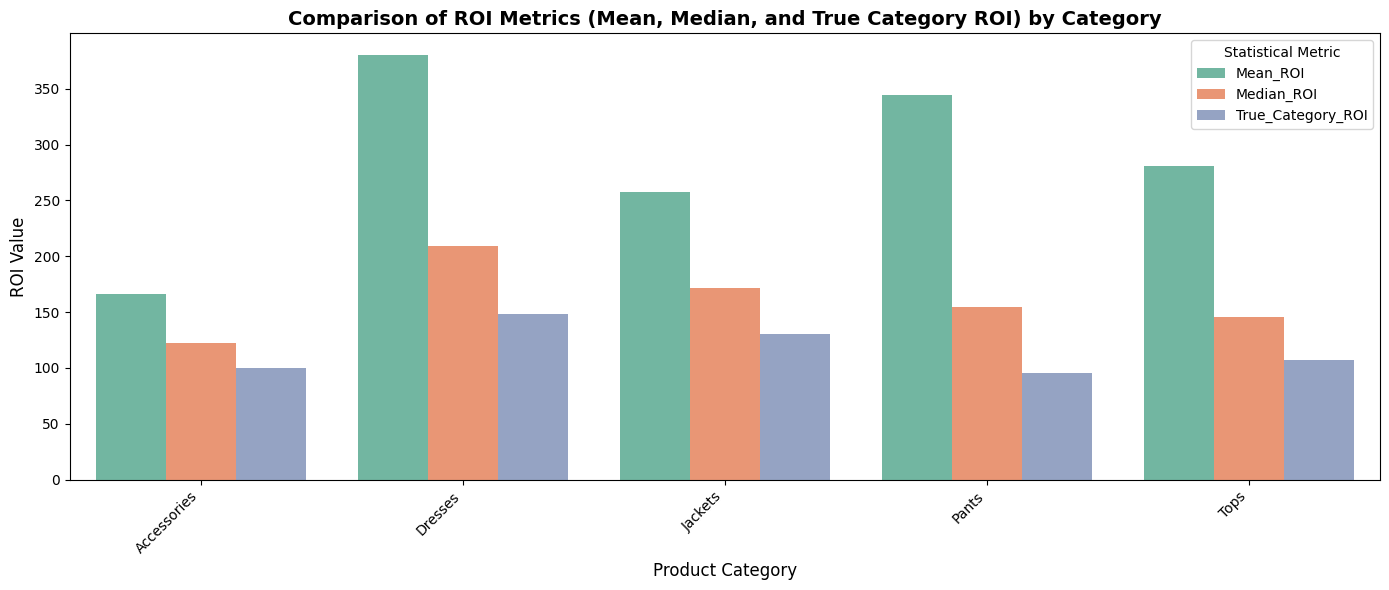

In [42]:
# 1. Basic summary + calculation of revenue and cost sums for True_Category_ROI
category_summary = (
    new_table_merge.groupby("Product_Category")
    .agg(
        Mean_ROI=("ROI", "mean"),
        Median_ROI=("ROI", "median"),
        Campaign_Count=("Campaign_ID", "nunique"),
        Total_Revenue=("Revenue_Generated", "sum"),  # Total revenue for the category
        Total_Cost=("Cost", "sum")                   # Total cost for the category
    )
    .reset_index()
)

# 2. Separate operation on the resulting table: calculating True_Category_ROI on a weighted basis
category_summary["True_Category_ROI"] = (
    category_summary["Total_Revenue"] - category_summary["Total_Cost"]
) / category_summary["Total_Cost"]

# 3. Displaying the text table in the console (sorted by the new metric)
print("=" * 70)
print("CAMPAIGN ANALYSIS SUMMARY BY CATEGORY (INCLUDING TRUE ROI):")
print("=" * 70)
print(category_summary.sort_values(by="True_Category_ROI", ascending=False))
print("=" * 70)

# 4. Preparing data for the chart (taking Mean, Median, and True_Category_ROI)
chart_data = category_summary.melt(
    id_vars="Product_Category",
    value_vars=["Mean_ROI", "Median_ROI", "True_Category_ROI"],
    var_name="Metric",
    value_name="ROI_Value"
)

# 5. Configuring and plotting the chart
plt.figure(figsize=(14, 6))

sns.barplot(
    data=chart_data,
    x="Product_Category",
    y="ROI_Value",
    hue="Metric",
    palette="Set2"
)

# 6. Embellishing the chart
plt.title("Comparison of ROI Metrics (Mean, Median, and True Category ROI) by Category", fontsize=14, fontweight='bold')
plt.xlabel("Product Category", fontsize=12)
plt.ylabel("ROI Value", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend(title="Statistical Metric")
plt.tight_layout()

# 7. Displaying the chart
plt.show()

The highest real ROI is achieved by the `Dresses` category (148.6), followed by `Jackets` (130.4) and `Tops` (107.3). The least profitable categories are `Pants` (95.8) and `Accessories` (99.5). It is worth noting that the real ROI for the `Tops` category is based on only a single executed campaign. 

The naive average (`Mean_ROI`) would suggest that `Pants` is the second most profitable category—however, after recalculating using sums (`True_Category_ROI`), it turns out to be the weakest, highlighting the risk of flawed budget allocation decisions when using the incorrect metric.

<a id="task8"></a>
## Task 8: Advanced Visualization of Marketing Flows and Performance

*(Influencers → Campaigns → Platforms → Categories)*

---

## Business Objective
Identify key revenue drivers by analysing multi-level connections among creators (influencers), the campaigns they run, the platforms they use, and the product categories generated. 

**Main Research Question:** 
> *Which influencers generate the highest revenue in specific categories?*
> *Through which platforms do influencers drive revenue for specific categories?*

### 🟢 Visualization: Sankey Diagram
*   **Tool:** `plotly`
*   **Flow Structure:** `Influencer` → `Campaign` → `Platform` → `Product Category`
*   **Logic:** The width (thickness) of the flow on the diagram must be proportional to the generated revenue (`Revenue_Generated`) or profit.
*   **Goal:** To showcase the full spectrum of budget distribution and returns within a multi-level structure.

In [43]:
# 1. Basic aggregation
sankey_data = new_table_merge.groupby(['Source_Influencer_ID', 'Product_Category'])['Revenue_Generated'].sum().reset_index()

# SORT EVERYTHING BY HIGHEST REVENUE
sankey_data = sankey_data.sort_values(by='Revenue_Generated', ascending=False)


# 2. Top influencer in each category (sorted so that the highest revenue is at the top)
top_influencer_per_category = (
    sankey_data.sort_values(['Product_Category', 'Revenue_Generated'], ascending=[True, False])
    .groupby('Product_Category')
    .first()
    .reset_index()
    .sort_values(by='Revenue_Generated', ascending=False)
)

print("--- TOP INFLUENCER PER CATEGORY (BY HIGHEST REVENUE) ---")
print(top_influencer_per_category)


# 3. Aggregation with platform
sankey_platform_data = new_table_merge.groupby(
    ['Platform', 'Source_Influencer_ID', 'Product_Category']
)['Revenue_Generated'].sum().reset_index()

sankey_platform_data = sankey_platform_data.sort_values(by='Revenue_Generated', ascending=False)

print("\n--- SAMPLE DATA (BY HIGHEST REVENUE) ---")
print(sankey_platform_data.head(10))


# 4. Dominant platforms across categories
platform_category_summary = (
    sankey_platform_data.groupby(['Platform', 'Product_Category'])['Revenue_Generated']
    .sum()
    .reset_index()
    .sort_values(['Product_Category', 'Revenue_Generated'], ascending=[True, False])
)

print("\n--- WHICH PLATFORMS DOMINATE IN CATEGORIES (BY HIGHEST REVENUE) ---")
print(platform_category_summary)

import plotly.io as pio
pio.renderers.default = "notebook_connected"

--- TOP INFLUENCER PER CATEGORY (BY HIGHEST REVENUE) ---
  Product_Category Source_Influencer_ID  Revenue_Generated
1          Dresses               INF008        28644078.16
2          Jackets               INF008        26677271.65
3            Pants               INF012        20325341.21
0      Accessories               INF008        18601317.31
4             Tops               INF012        10610047.70

--- SAMPLE DATA (BY HIGHEST REVENUE) ---
     Platform Source_Influencer_ID Product_Category  Revenue_Generated
26     TikTok               INF012            Pants        20325341.21
43    YouTube               INF008      Accessories        18601317.31
44    YouTube               INF008          Dresses        15254159.96
8   Instagram               INF019          Dresses        14021065.22
25     TikTok               INF012          Dresses        13926032.76
35     TikTok               INF019          Dresses        13901878.49
36     TikTok               INF019          Jacket

In [44]:
platform_category_summary = (
    sankey_platform_data.groupby(['Platform', 'Product_Category'])['Revenue_Generated']
    .sum()
    .reset_index()
    # Change order: highest revenue first, then category alphabetically
    .sort_values(['Revenue_Generated', 'Product_Category'], ascending=[False, True])
)

print("\n--- WHICH PLATFORMS DOMINATE IN CATEGORIES (BY HIGHEST REVENUE) ---")
print(platform_category_summary)


--- WHICH PLATFORMS DOMINATE IN CATEGORIES (BY HIGHEST REVENUE) ---
    Platform Product_Category  Revenue_Generated
4     TikTok            Pants        56724397.27
6    YouTube      Accessories        55793260.60
3     TikTok          Jackets        42983861.34
1  Instagram          Jackets        42268807.29
7    YouTube          Dresses        41951069.11
2     TikTok          Dresses        40816615.18
0  Instagram          Dresses        40476768.64
5     TikTok             Tops        31836115.91


The highest revenues in the respective categories are generated by influencer `INF008` (across three categories: `Dresses`, `Jackets`, and `Accessories`) and `INF012` (in `Pants` and `Tops`). Examining influencers, platforms, and categories together, the top results are achieved by `INF012` on `TikTok` within the `Pants` category. Regarding platforms, the highest revenues were driven by `Pants` on `TikTok`, `Accessories` on `YouTube`, and `Jackets` on `TikTok`.

Resorting to unclean kill browser.


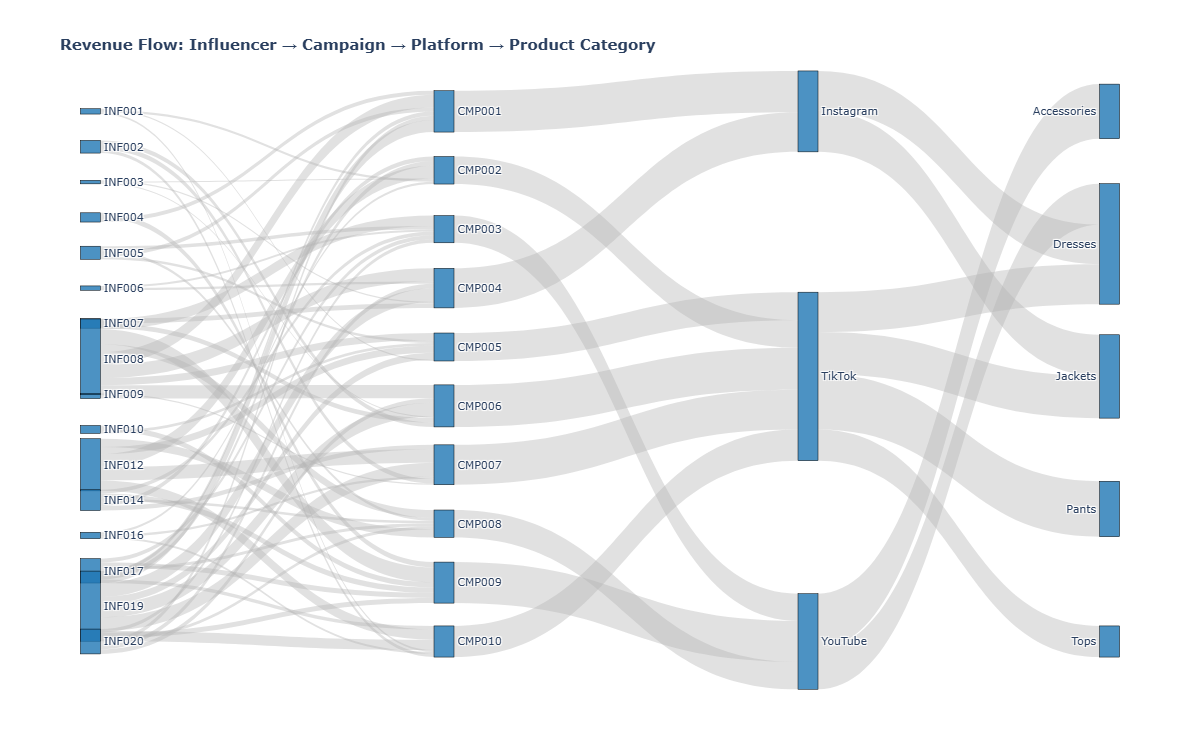

In [45]:
import plotly.io as pio
import plotly.graph_objects as go
import pandas as pd
import re
from IPython.display import Image, display

# Ustaw renderer (jedna linia, jeden raz)
pio.renderers.default = "notebook_connected"

# Funkcja do poprawnego sortowania numerycznego ID
def extract_number(text):
    match = re.search(r'\d+', str(text))
    return int(match.group()) if match else 0

# 1. Przygotowanie poziomów danych
flow1 = new_table_merge.groupby(['Source_Influencer_ID', 'Campaign_ID'])['Revenue_Generated'].sum().reset_index()
flow1.columns = ['source', 'target', 'value']

flow2 = new_table_merge.groupby(['Campaign_ID', 'Platform'])['Revenue_Generated'].sum().reset_index()
flow2.columns = ['source', 'target', 'value']

flow3 = new_table_merge.groupby(['Platform', 'Product_Category'])['Revenue_Generated'].sum().reset_index()
flow3.columns = ['source', 'target', 'value']

sankey_links = pd.concat([flow1, flow2, flow3], ignore_index=True)

# 2. Tworzenie posortowanych list
influencers_list = sorted(new_table_merge['Source_Influencer_ID'].unique().tolist(), key=lambda x: (extract_number(x), str(x)))
campaigns_list = sorted(list(new_table_merge['Campaign_ID'].unique()))
platforms_list = sorted(list(new_table_merge['Platform'].unique()))
categories_list = sorted(list(new_table_merge['Product_Category'].unique()))

all_nodes = influencers_list + campaigns_list + platforms_list + categories_list

node_dict = {node: i for i, node in enumerate(all_nodes)}
sankey_links['source_idx'] = sankey_links['source'].map(node_dict)
sankey_links['target_idx'] = sankey_links['target'].map(node_dict)

# 3. Współrzędne X i Y
node_x = {}
node_y = {}

def assign_y_coords(node_list, x_pos):
    n = len(node_list)
    for i, node in enumerate(node_list):
        node_x[node] = x_pos
        node_y[node] = 0.02 + (i / max(1, n - 1)) * 0.93 if n > 1 else 0.5

assign_y_coords(influencers_list, 0.01)
assign_y_coords(campaigns_list, 0.35)
assign_y_coords(platforms_list, 0.70)
assign_y_coords(categories_list, 0.99)

x_coords = [node_x[node] for node in all_nodes]
y_coords = [node_y[node] for node in all_nodes]

# 4. Generowanie wykresu Sankeya
fig = go.Figure(data=[go.Sankey(
    node = dict(
      pad = 15,
      thickness = 20,
      line = dict(color = "black", width = 0.5),
      label = all_nodes,
      x = x_coords,
      y = y_coords,
      color = "rgba(31, 119, 180, 0.8)"
    ),
    link = dict(
      source = sankey_links['source_idx'],
      target = sankey_links['target_idx'],
      value = sankey_links['value'],
      color = "rgba(180, 180, 180, 0.4)"
  ))])

fig.update_layout(
    title_text="<b>Revenue Flow: Influencer → Campaign → Platform → Product Category</b>",
    font_size=11,
    width=1200,
    height=750
)

# 5. Zapis PNG + HTML i wyświetlenie obrazka
fig.write_image("sankey.png", width=1200, height=750)
fig.write_html("sankey.html")
display(Image("sankey.png"))

`TikTok` generated the highest revenue (USD 172 million) among all utilized platforms and is the sole platform supporting campaigns across all item categories, excluding the `Accessories` category. `TikTok` was used for the highest number of campaigns, totalling 5. `YouTube` ranks second among platforms (USD 98 million), with 3 campaigns executed across 2 product categories. In third and last place is the `Instagram` platform, accounting for USD 83 million in revenue, 2 campaigns, and 2 product categories.

<a id="summary"></a> 

### Summary

The analysis utilized the *Influencer Marketing Campaign Analysis* dataset from Kaggle. **SQL** was used for relational data extraction and analysis, while **Python** was applied for validation, aggregation, and data visualization.

#### Key Stages and Results of the Analysis:

* **Data Quality and Consistency Audit:** 
  * Verified influencer tier consistency, detecting **13 discrepancies** between the internal system and the source database.
  * A comparison against standard industry thresholds revealed that the Tier classification in the database relies on relative ranking rather than absolute metric values.
  * Quality tests performed in Python confirmed zero duplicates and no data type errors. A total of 36 `NULL` values were identified in the `Main_Product_ID` column; however, these did not impact the findings as the column was excluded from subsequent models.

* **Campaign Aggregation:** 
  * Calculated total revenues, costs, and ROI metrics for individual campaigns. 
  * **Conclusion:** **Campaign 9** emerged as the leader in terms of return on investment efficiency.

* **Creator Profiling:** 
  * Developed a comprehensive performance profile incorporating campaign counts, conversions, and generated revenue.
  * **Scale Leaders:** *BeautyBuzz*, *SustainableChic*, and *VintageFinds*.
  * **High Potential (Unit Efficiency):** *TheStreetLook*, *MinimalistMan*, and *TravelAndStyle*—creators generating strong performance with fewer campaigns, warranting further monitoring. Creators generating revenues above the market average were also filtered out.

  * **Benchmark Analysis and Trends:** 
  * Investigated ROI benchmarks across individual platforms (demonstrating relatively minor differences in performance) and analysed month-over-month (MoM) revenue trends.

* **Product Category Impact:** 
  * The highest ROI was recorded for the **Dresses** category. The difference between the highest and lowest aggregated category ROI was **approximately 50 percentage points**.
  * The naive average ROI would mistakenly point to `Pants` as the second most profitable category—after recalculating using revenue and cost sums, it turned out to be the weakest, highlighting the risk of flawed budget decisions when using the incorrect metric.

* **Flow Visualization (Sankey Diagram):** 
  * Designed a complete revenue flow chain (*influencers → campaigns → platforms → categories*), demonstrating, among other things, that the single largest revenue stream in the breakdown was generated by the `Pants` category on the `TikTok` platform.

* **Thank you for your time and for reading my portfolio!**